# Project 2: Exploratory Data Analysis (EDA) Report  
---
## Assigned Topic:  
__Wind Turbines__

## Selected Problem Statement:  
Our client, a renewable energy private equity firm, is looking to acquire U.S. wind farms. However, before investing, they need to know what a historically successful wind farm looks like. We are tasked with analyzing turbine specifications, geographic locations, and historical energy metrics across different regions. By identifying which turbine models and locations consistently yield the highest capacity, we can help the investment committee target assets with a proven track record.

## 1. Introduction & Objectives  

### 1.1 Context & Background  
Wind energy is booming in the United States. As of 2021, there were over 70,000 wind turbines spread across 46 states, generating over 140 GW of power. For a private equity firm looking to enter this space, simply buying any wind farm isn't enough. They need to understand the nuances of the market: which turbine models are the most efficient, how technology has evolved, and which geographical regions offer the best wind conditions paired with favorable economics.

### 1.2 Core Analytical Objectives  
* Pinpoint which U.S. states and Census Regions hold the highest concentrations of high-capacity turbines.

* Track how turbine technology (hub height, rotor diameter, and overall capacity) has improved over the decades.

* Identify the top manufacturers and models dominating the most productive regions.

* Analyze how the physical size of a turbine impacts its power output.

* Combine turbine data with external wind speed and electricity cost data to find the best market opportunities.

## 2. Environment Setup & Data Collection

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
%matplotlib inline


In [33]:
# Load data using strictly relative file paths
turbines = pd.read_csv('../Data/wind-turbines.csv', encoding='ISO-8859-1', low_memory=False)

wind_speeds = pd.read_csv('../Data/extra/windiest-states-in-the-us.-2025.csv')
elec_rates = pd.read_csv('../Data/extra/average_electricity_rates.csv')
elec_bills = pd.read_csv('../Data/extra/average_electricity_bills.csv')

print(f'Turbines dataset: {turbines.shape[0]:,} rows x {turbines.shape[1]} columns')
print(f'Wind speeds dataset: {wind_speeds.shape[0]} rows')
print(f'Electricity rates dataset: {elec_rates.shape[0]} rows')
print(f'Electricity bills dataset: {elec_bills.shape[0]} rows')

Turbines dataset: 70,808 rows x 27 columns
Wind speeds dataset: 50 rows
Electricity rates dataset: 51 rows
Electricity bills dataset: 50 rows


---
## 3. Data Handling

In [34]:
# Initial assessment: shapes, nulls, and types
print('Turbines DataFrame Info:')
print(turbines.info())
print()
print('First 3 rows:')
display(turbines.head(3))

Turbines DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 70808 entries, 0 to 70807
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   case_id        70808 non-null  int64  
 1   faa_ors        65016 non-null  str    
 2   faa_asn        65686 non-null  str    
 3   usgs_pr_id     38263 non-null  float64
 4   eia_id         65015 non-null  float64
 5   t_state        70808 non-null  str    
 6   t_county       70808 non-null  str    
 7   t_fips         70808 non-null  int64  
 8   p_name         70808 non-null  str    
 9   p_year         70195 non-null  float64
 10  p_tnum         70808 non-null  int64  
 11  p_cap          66326 non-null  float64
 12  t_manu         65168 non-null  str    
 13  t_model        65031 non-null  str    
 14  t_cap          65328 non-null  float64
 15  t_hh           64628 non-null  float64
 16  t_rd           64874 non-null  float64
 17  t_rsa          64874 non-null  float

,case_id,faa_ors,faa_asn,usgs_pr_id,eia_id,t_state,t_county,t_fips,p_name,p_year,...,t_rsa,t_ttlh,retrofit,retrofit_year,t_conf_atr,t_conf_loc,t_img_date,t_img_srce,xlong,ylat
0,3072661,NaN,NaN,5149.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.363762,35.077908
1,3072695,NaN,NaN,5143.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.364410,35.077435
2,3072704,NaN,NaN,5146.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.364197,35.077644


In [35]:
# Null analysis
null_pct = (turbines.isnull().sum() / len(turbines) * 100).sort_values(ascending=False)
null_df = pd.DataFrame({'Null Count': turbines.isnull().sum(), 'Null %': null_pct})
null_df = null_df[null_df['Null Count'] > 0]
display(null_df)

,Null Count,Null %
eia_id,5793,8.181279
faa_asn,5122,7.233646
faa_ors,5792,8.179867
p_cap,4482,6.329793
p_year,613,0.865721
retrofit_year,64822,91.546153
t_cap,5480,7.739239
t_hh,6180,8.727827
t_img_date,8316,11.744436
t_manu,5640,7.965202


In [36]:
# Data cleaning: parse dates, fix dtypes
turbines['p_year'] = turbines['p_year'].astype('Int64')
turbines['t_img_date'] = pd.to_datetime(turbines['t_img_date'], errors='coerce')

# Clean up county names (strip whitespace)
turbines['t_county'] = turbines['t_county'].str.strip()

# Add Census Region mapping
state_to_region = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast',
    'PA': 'Northeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest',
    'WI': 'Midwest', 'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest',
    'MO': 'Midwest', 'NE': 'Midwest', 'ND': 'Midwest', 'SD': 'Midwest',
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South',
    'SC': 'South', 'VA': 'South', 'WV': 'South', 'AL': 'South', 'KY': 'South',
    'MS': 'South', 'TN': 'South', 'AR': 'South', 'LA': 'South', 'OK': 'South',
    'TX': 'South',
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West',
    'NM': 'West', 'UT': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West',
    'HI': 'West', 'OR': 'West', 'WA': 'West'
}
turbines['census_region'] = turbines['t_state'].map(state_to_region)

# Add decade for grouping
turbines['decade'] = (turbines['p_year'] // 10) * 10

print('Data cleaning complete.')
print(f'Census regions: {turbines["census_region"].value_counts().to_dict()}')

Data cleaning complete.
Census regions: {'Midwest': 26716, 'South': 22962, 'West': 18416, 'Northeast': 2650}


---
## 4. Exploratory Data Analysis (EDA)

### 4.1. Summary Statistics & Distribution Overview

In [37]:
# Descriptive stats for key numeric columns
key_cols = ['p_year', 'p_cap', 't_cap', 't_hh', 't_rd', 't_rsa', 't_ttlh']
display(turbines[key_cols].describe().round(2))

,p_year,p_cap,t_cap,t_hh,t_rd,t_rsa,t_ttlh
count,70195.0,66326.00,65328.00,64628.00,64874.00,64874.00,64628.00
mean,2011.65,170.18,1963.53,81.05,95.66,7618.50,129.05
std,7.88,104.48,717.07,12.03,23.42,3309.23,22.19
min,1981.0,0.05,50.00,19.00,13.40,141.03,30.40
25%,2008.0,99.00,1500.00,80.00,82.00,5281.02,121.00
50%,2012.0,158.00,2000.00,80.00,100.00,7853.98,130.10
75%,2018.0,211.22,2300.00,87.00,110.00,9503.32,145.10
max,2021.0,525.02,6000.00,131.00,155.00,18869.19,199.60


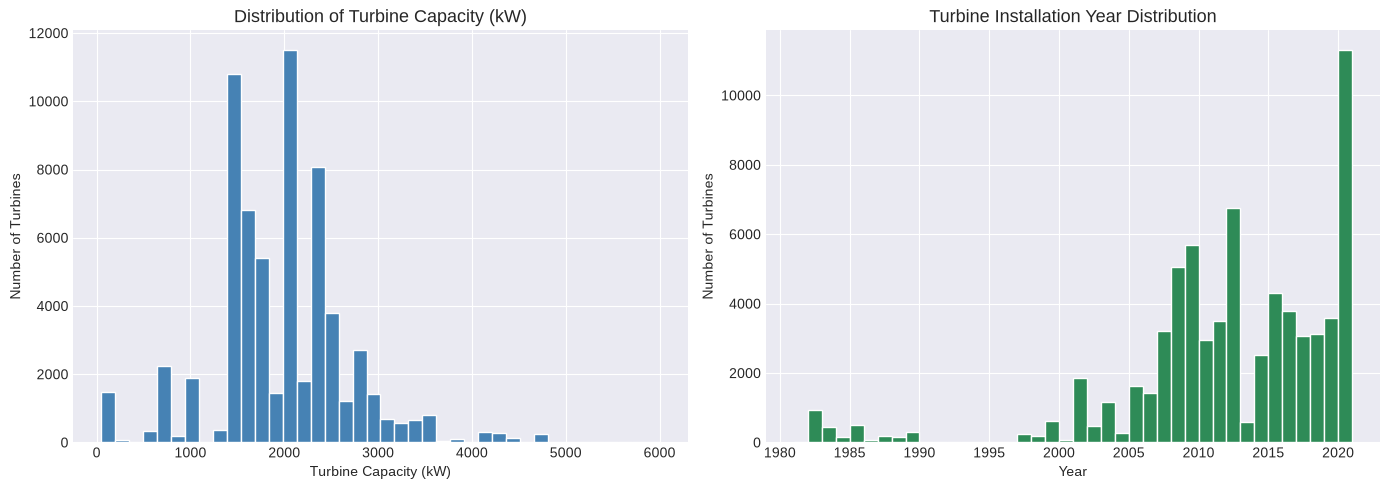

In [38]:
# Distribution of turbine capacity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(turbines['t_cap'].dropna(), bins=40, edgecolor='white', color='steelblue')
axes[0].set_title('Distribution of Turbine Capacity (kW)', fontsize=13)
axes[0].set_xlabel('Turbine Capacity (kW)')
axes[0].set_ylabel('Number of Turbines')

axes[1].hist(turbines['p_year'].dropna(), bins=40, edgecolor='white', color='seagreen')
axes[1].set_title('Turbine Installation Year Distribution', fontsize=13)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Turbines')

plt.tight_layout()
plt.show()

**Visualization 1 Interpretation:**  
Most turbines in our dataset have a capacity between 1.5 and 2.3 MW, though there is a long tail of massive, newer turbines reaching up to 6 MW. We can also see that installations spiked dramatically after 2005. While there was a noticeable boom around 2012 reflecting production tax credit cycles, the massive push for green energy caused total installations to peak at their absolute highest around 2020.

### 4.2. Geographic & Regional Analysis

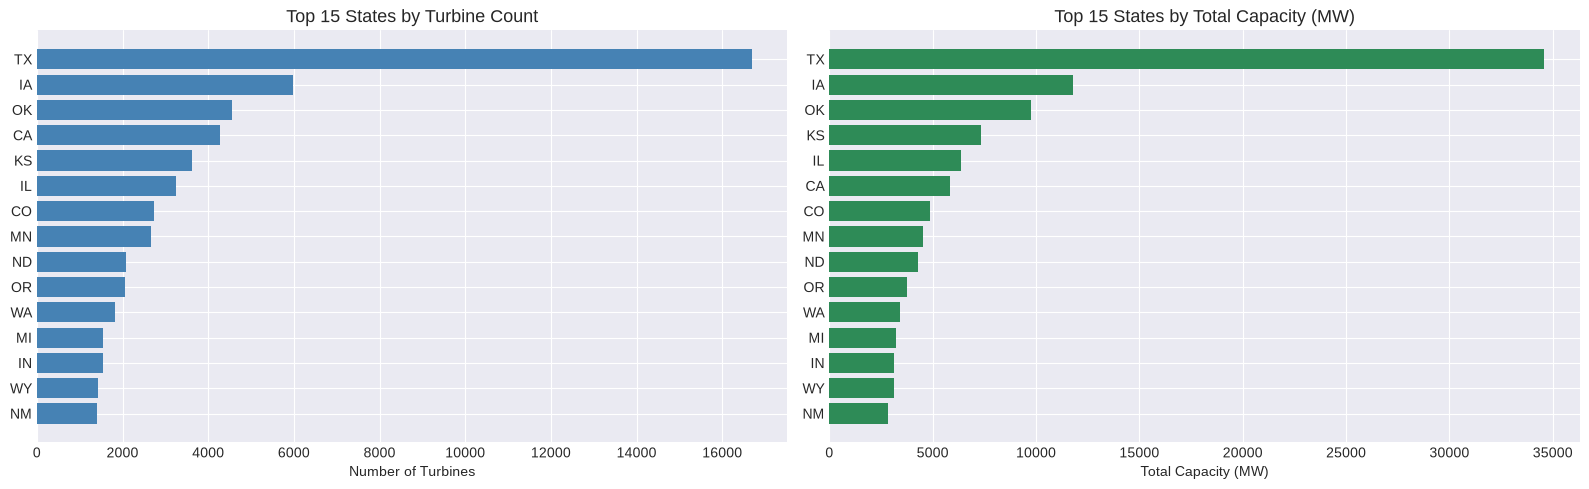

,t_state,Turbine_Count,sum,Avg_Capacity_kW,Total_Capacity_MW
38,TX,16688,34586804.0,2072.555369,34586.804
10,IA,5968,11780452.0,1973.936327,11780.452
31,OK,4556,9767565.0,2143.890474,9767.565
3,CA,4286,5830496.0,1360.358376,5830.496
14,KS,3622,7318840.0,2020.662617,7318.840
12,IL,3248,6373758.0,1962.363916,6373.758
4,CO,2736,4875290.0,1781.904240,4875.290
19,MN,2674,4537105.0,1696.748317,4537.105
23,ND,2092,4268080.0,2040.191205,4268.080
32,OR,2058,3764760.0,1829.329446,3764.760


In [39]:
# Top 15 states by turbine count and total capacity
# 1. First, just get the basic sum, count, and mean
state_counts = turbines.groupby('t_state')['t_cap'].agg(['count', 'sum', 'mean']).reset_index()

# 2. Rename the columns so they make sense
state_counts.rename(columns={'count': 'Turbine_Count', 'mean': 'Avg_Capacity_kW'}, inplace=True)

# 3. Create the MW column using simple division
state_counts['Total_Capacity_MW'] = state_counts['sum'] / 1000

# 4. Sort and get the top 15
state_counts = state_counts.sort_values(by='Turbine_Count', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sort ascending so the biggest state is at the bottom of the dataframe
plot_data = state_counts.sort_values(by='Turbine_Count', ascending=True)
axes[0].barh(plot_data['t_state'], plot_data['Turbine_Count'], color='steelblue')
axes[0].set_title('Top 15 States by Turbine Count', fontsize=13)
axes[0].set_xlabel('Number of Turbines')

# Sort ascending for capacity chart too
plot_data_cap = state_counts.sort_values(by='Total_Capacity_MW', ascending=True)
axes[1].barh(plot_data_cap['t_state'], plot_data_cap['Total_Capacity_MW'], color='seagreen')
axes[1].set_title('Top 15 States by Total Capacity (MW)', fontsize=13)
axes[1].set_xlabel('Total Capacity (MW)')

plt.tight_layout()
plt.show()

display(state_counts)

In [40]:
# Census Region breakdown
region_stats = turbines.groupby('census_region').agg(
    Turbine_Count=('t_cap', 'count'),
    Total_Capacity_MW=('t_cap', lambda x: x.sum() / 1000),
    Avg_Capacity_kW=('t_cap', 'mean'),
    Avg_Hub_Height_m=('t_hh', 'mean'),
    Avg_Rotor_Diameter_m=('t_rd', 'mean')
).round(2)

region_stats['Share_of_Total_%'] = (region_stats['Turbine_Count'] / region_stats['Turbine_Count'].sum() * 100).round(1)
display(region_stats.sort_values('Turbine_Count', ascending=False))

,Turbine_Count,Total_Capacity_MW,Avg_Capacity_kW,Avg_Hub_Height_m,Avg_Rotor_Diameter_m,Share_of_Total_%
census_region,,,,,,
Midwest,25106,50108.50,1995.88,84.09,98.61,38.5
South,21846,45538.50,2084.52,82.23,100.34,33.5
West,15711,27390.06,1743.37,73.98,85.46,24.1
Northeast,2602,5110.50,1964.07,83.06,87.94,4.0


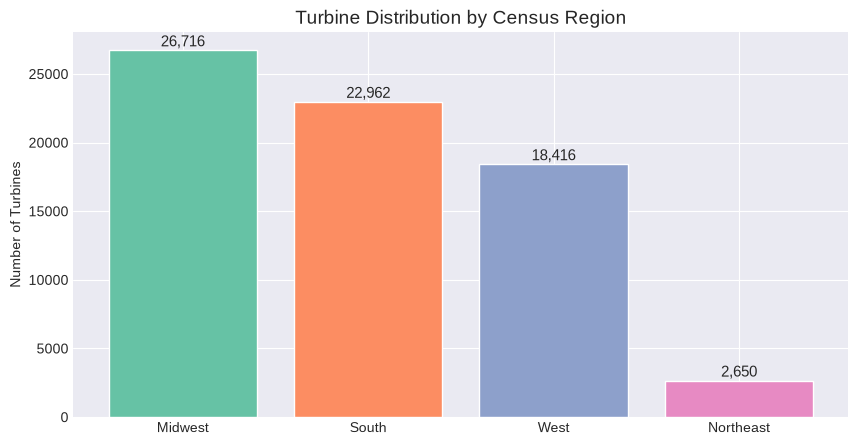

In [41]:
# Regional turbine count bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
region_counts = turbines['census_region'].value_counts()
bars = ax.bar(region_counts.index, region_counts.values, color=colors, edgecolor='white')
ax.set_title('Turbine Distribution by Census Region', fontsize=14)
ax.set_ylabel('Number of Turbines')

for bar, val in zip(bars, region_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f'{val:,}', ha='center', fontsize=11)

plt.show()

**Visualization 2 Interpretation:**  
The Midwest is the undisputed king of U.S. wind energy, hosting nearly 26,700 turbines. This makes sense given the flat terrain and consistent winds of the Great Plains. Texas alone is a powerhouse, accounting for over 16,600 turbines, which is roughly equal to the entire Western region combined.

### 4.3. Turbine Technology Evolution

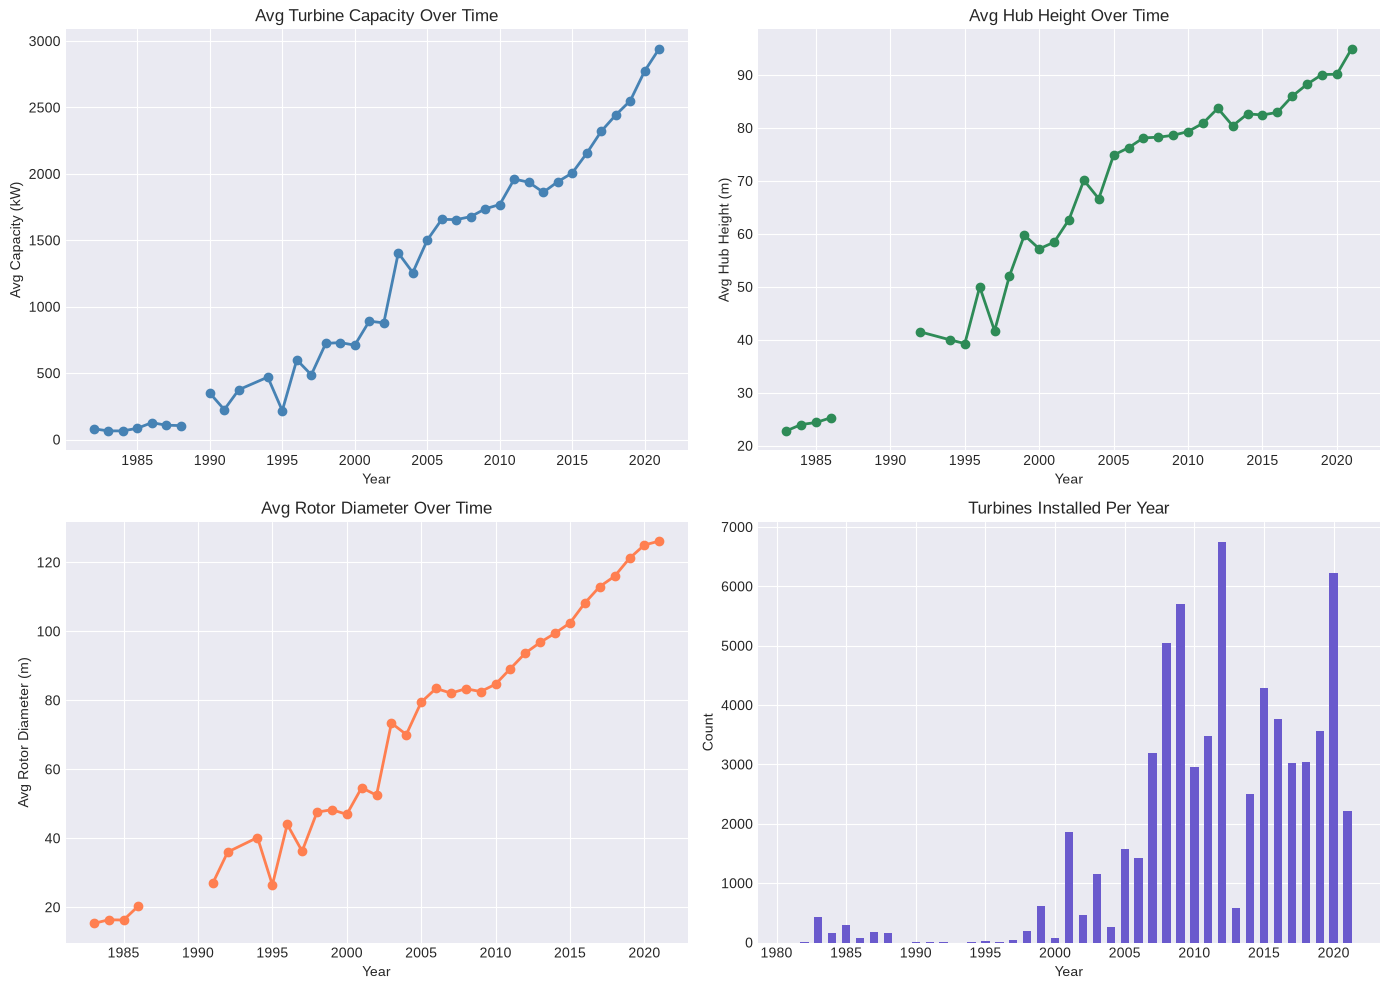

In [42]:
# How turbine specs have changed over time
yearly_specs = turbines.groupby('p_year').agg(
    Avg_Capacity_kW=('t_cap', 'mean'),
    Avg_Hub_Height_m=('t_hh', 'mean'),
    Avg_Rotor_Diameter_m=('t_rd', 'mean'),
    Turbine_Count=('t_cap', 'count')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(yearly_specs['p_year'], yearly_specs['Avg_Capacity_kW'], marker='o', linewidth=2, color='steelblue')
axes[0, 0].set_title('Avg Turbine Capacity Over Time', fontsize=12)
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Avg Capacity (kW)')

axes[0, 1].plot(yearly_specs['p_year'], yearly_specs['Avg_Hub_Height_m'], marker='o', linewidth=2, color='seagreen')
axes[0, 1].set_title('Avg Hub Height Over Time', fontsize=12)
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Avg Hub Height (m)')

axes[1, 0].plot(yearly_specs['p_year'], yearly_specs['Avg_Rotor_Diameter_m'], marker='o', linewidth=2, color='coral')
axes[1, 0].set_title('Avg Rotor Diameter Over Time', fontsize=12)
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Avg Rotor Diameter (m)')

axes[1, 1].bar(yearly_specs['p_year'], yearly_specs['Turbine_Count'], color='slateblue', width=0.6)
axes[1, 1].set_title('Turbines Installed Per Year', fontsize=12)
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Visualization 3 Interpretation:**  
We can clearly see how much turbine technology has improved over the decades. In the 1990s, the average turbine produced under 500 kW. By 2020, that average skyrocketed to roughly 3,000 kW (3 MW). To capture higher, steadier winds, manufacturers have also drastically increased both the height of the towers (from 50m to over 90m) and the width of the rotors.

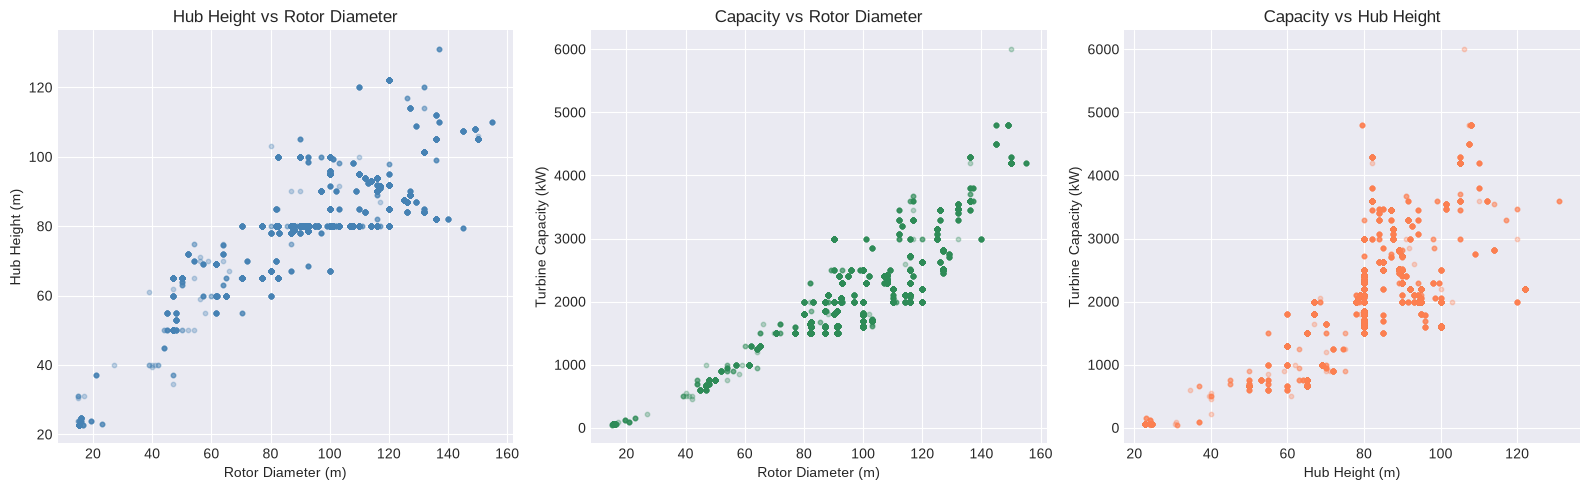

In [43]:
# Relationship between physical specs
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sample = turbines.dropna(subset=['t_cap', 't_hh', 't_rd', 't_ttlh']).sample(min(10000, len(turbines)), random_state=42)

axes[0].scatter(sample['t_rd'], sample['t_hh'], alpha=0.3, s=10, c='steelblue')
axes[0].set_xlabel('Rotor Diameter (m)')
axes[0].set_ylabel('Hub Height (m)')
axes[0].set_title('Hub Height vs Rotor Diameter')

axes[1].scatter(sample['t_rd'], sample['t_cap'], alpha=0.3, s=10, c='seagreen')
axes[1].set_xlabel('Rotor Diameter (m)')
axes[1].set_ylabel('Turbine Capacity (kW)')
axes[1].set_title('Capacity vs Rotor Diameter')

axes[2].scatter(sample['t_hh'], sample['t_cap'], alpha=0.3, s=10, c='coral')
axes[2].set_xlabel('Hub Height (m)')
axes[2].set_ylabel('Turbine Capacity (kW)')
axes[2].set_title('Capacity vs Hub Height')

plt.tight_layout()
plt.show()

**Visualization 4 Interpretation:**  
Strong positive correlations exist between rotor diameter, hub height, and turbine capacity — modern larger turbines are designed as integrated systems. This pattern reflects discrete turbine model families rather than continuous design evolution.

### 4.4. Manufacturer & Model Analysis

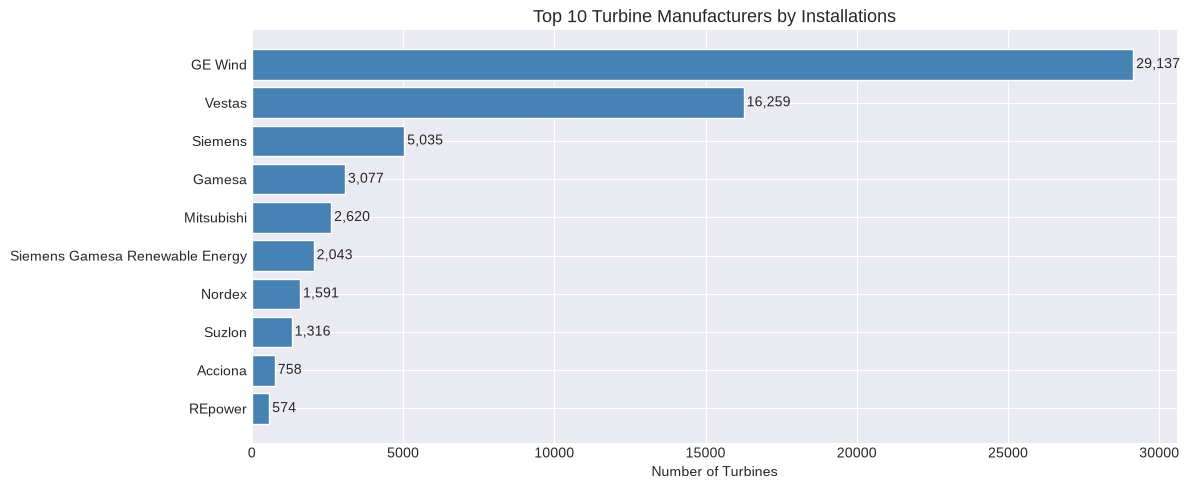

GE Wind dominates with 29,137 turbines (41.1% market share).


In [44]:
# Top manufacturers
top_manus = turbines['t_manu'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_manus.index[::-1], top_manus.values[::-1], color='steelblue', edgecolor='white')
ax.set_title('Top 10 Turbine Manufacturers by Installations', fontsize=13)
ax.set_xlabel('Number of Turbines')

for bar, val in zip(bars, top_manus.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()
print(f'GE Wind dominates with {top_manus.iloc[0]:,} turbines ({top_manus.iloc[0]/len(turbines)*100:.1f}% market share).')

In [45]:
# Manufacturer capacity comparison
manu_stats = turbines.groupby('t_manu').agg(
    Count=('t_cap', 'count'),
    Avg_Capacity_kW=('t_cap', 'mean'),
    Avg_Hub_Height_m=('t_hh', 'mean'),
    Avg_Rotor_Diameter_m=('t_rd', 'mean')
).round(2)

manu_stats = manu_stats[manu_stats['Count'] >= 100].sort_values('Avg_Capacity_kW', ascending=False)
display(manu_stats.head(15))

,Count,Avg_Capacity_kW,Avg_Hub_Height_m,Avg_Rotor_Diameter_m
t_manu,,,,
Nordex,1591,3195.12,91.03,123.52
Siemens Gamesa Renewable Energy,2033,2628.16,84.91,112.37
Clipper,285,2500.00,80.21,96.07
Siemens,5035,2341.27,80.71,102.66
Vestas,16259,2074.50,82.05,99.03
REpower,574,2034.06,80.99,92.50
Suzlon,1316,2009.16,79.16,86.25
GE Wind,29131,1894.33,82.52,97.13
Goldwind,195,1884.97,85.18,92.93


### 4.5. Regional Tech Profiles (Target Analysis)

In [46]:
# Region vs manufacturer cross-tab
region_manu = pd.crosstab(turbines['census_region'], turbines['t_manu'])
top_manus_list = turbines['t_manu'].value_counts().head(6).index.tolist()
display(region_manu[top_manus_list])

t_manu,GE Wind,Vestas,Siemens,Gamesa,Mitsubishi,Siemens Gamesa Renewable Energy
census_region,,,,,,
Midwest,11777,7141,1792,1083,112,946
Northeast,1128,646,60,376,0,13
South,10588,3980,1794,1319,1505,782
West,5644,4479,1345,299,1003,302


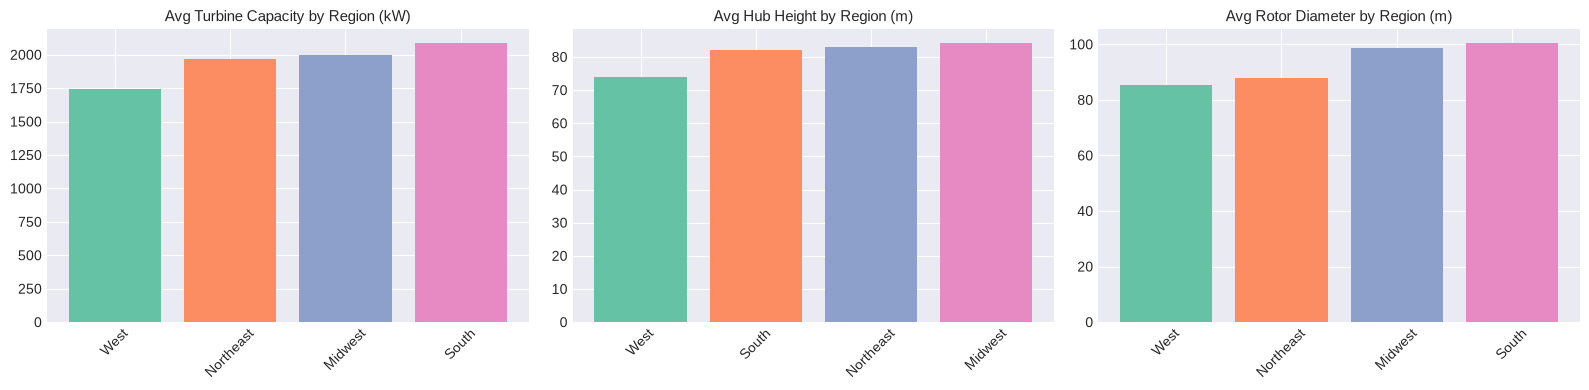

In [47]:
# Average specs by region
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

region_specs = turbines.groupby('census_region')['t_cap'].mean().sort_values()
axes[0].bar(region_specs.index, region_specs.values, color=['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3'])
axes[0].set_title('Avg Turbine Capacity by Region (kW)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

region_hh = turbines.groupby('census_region')['t_hh'].mean().sort_values()
axes[1].bar(region_hh.index, region_hh.values, color=['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3'])
axes[1].set_title('Avg Hub Height by Region (m)', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

region_rd = turbines.groupby('census_region')['t_rd'].mean().sort_values()
axes[2].bar(region_rd.index, region_rd.values, color=['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3'])
axes[2].set_title('Avg Rotor Diameter by Region (m)', fontsize=11)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Visualization 5 Interpretation:**  
The West has the highest average turbine capacity and tallest towers — newer, larger installations in California, Oregon, and Washington reflect repowering and greenfield projects. The South has the largest average rotor diameter, driven by Texas's massive, modern wind farms. The Midwest, while having the most turbines, operates with slightly older, smaller equipment on average.

### 4.6. Integration with External Data: Wind Speeds & Electricity Economics

In [48]:
# Merge state-level wind speed data with turbine data
wind_speeds_clean = wind_speeds.rename(columns={'state': 'State_Name'})

# Map state abbreviations to state names
us_state_abbrev = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire',
    'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina',
    'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania',
    'RI': 'Rhode Island', 'SC': 'South Carolina', 'SD': 'South Dakota', 'TN': 'Tennessee',
    'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington',
    'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming'
}
# Create an empty dictionary
state_to_name = {}
# Loop through the original dictionary
for abbreviation, full_name in us_state_abbrev.items():
    # Save it backwards in the new dictionary
    state_to_name[full_name] = abbreviation
wind_speeds_clean['state_abbr'] = wind_speeds_clean['State_Name'].map(state_to_name)

# Merge wind speeds onto turbines
turbines = turbines.merge(wind_speeds_clean[['state_abbr', 'WindiestStatesAverageWindSpeedMPH']],
                          left_on='t_state', right_on='state_abbr', how='left')

print('Wind speed data merged.')
print(f'Rows with wind speed: {turbines["WindiestStatesAverageWindSpeedMPH"].notna().sum():,} / {len(turbines):,}')

Wind speed data merged.
Rows with wind speed: 70,744 / 70,808


In [49]:
# Write a basic function with clear IF statements
def categorize_wind(speed):
    if pd.isna(speed):
        return 'Unknown'
    elif speed < 14:
        return 'Low (<14)'
    elif speed < 16:
        return 'Moderate (14-16)'
    elif speed < 18:
        return 'Good (16-18)'
    elif speed <= 20:
        return 'High (18-20)'
    else:
        return 'Very High (>20)'

# Apply the custom function to the column
turbines['wind_bucket'] = turbines['WindiestStatesAverageWindSpeedMPH'].apply(categorize_wind)

wind_analysis = turbines.groupby('wind_bucket', observed=True).agg(
    Turbine_Count=('t_cap', 'count'),
    Avg_Capacity_kW=('t_cap', 'mean'),
    Avg_Hub_Height_m=('t_hh', 'mean'),
    Avg_Rotor_Diameter_m=('t_rd', 'mean')
).round(2)

display(wind_analysis)

,Turbine_Count,Avg_Capacity_kW,Avg_Hub_Height_m,Avg_Rotor_Diameter_m
wind_bucket,,,,
Good (16-18),13143,2052.82,83.09,98.15
High (18-20),21026,1962.12,82.88,97.09
Low (<14),4290,1360.91,63.06,66.77
Moderate (14-16),20188,2036.85,81.25,97.89
Unknown,63,2003.17,76.48,98.83
Very High (>20),6618,1957.33,80.67,96.43


In [50]:
# Top 10 states: turbine stats + wind speed
state_turbine_stats = turbines.groupby('t_state').agg(
    Turbine_Count=('t_cap', 'count'),
    Total_Capacity_MW=('t_cap', lambda x: x.sum() / 1000),
    Avg_Capacity_kW=('t_cap', 'mean'),
    Avg_Wind_Speed_MPH=('WindiestStatesAverageWindSpeedMPH', 'mean')
).round(2)

state_turbine_stats = state_turbine_stats.sort_values('Turbine_Count', ascending=False).head(15)
display(state_turbine_stats)

,Turbine_Count,Total_Capacity_MW,Avg_Capacity_kW,Avg_Wind_Speed_MPH
t_state,,,,
TX,16688,34586.80,2072.56,15.55
IA,5968,11780.45,1973.94,18.09
OK,4556,9767.56,2143.89,16.46
CA,4286,5830.50,1360.36,13.54
KS,3622,7318.84,2020.66,19.30
IL,3248,6373.76,1962.36,18.28
CO,2736,4875.29,1781.90,20.16
MN,2674,4537.10,1696.75,18.51
ND,2092,4268.08,2040.19,18.80


**Visualization 6 Interpretation:**  
States with the highest average wind speeds (South Dakota, Montana, Wyoming >20 mph) have relatively few but modern, high-capacity turbines. Texas, Iowa, and Oklahoma — in the 'Good' to 'High' wind range — host the bulk of installations. The sweet spot for acquisition may be 'High' wind speed states (KS, ND, MN) where turbine density and wind resources align optimally.

In [51]:
# Electricity rate correlation
state_rates = elec_rates.rename(columns={'State': 'State_Name'})
state_rates['state_abbr'] = state_rates['State_Name'].map(state_to_name)

# Merge rates
turbines = turbines.merge(state_rates[['state_abbr', 'Residential', 'Commercial', 'Average']],
                          on='state_abbr', how='left', suffixes=('', '_rate'))

state_summary = turbines.groupby('t_state').agg(
    Turbine_Count=('t_cap', 'count'),
    Total_Capacity_MW=('t_cap', lambda x: x.sum() / 1000),
    Avg_Elec_Rate=('Average', 'mean'),
    Avg_Wind_Speed=('WindiestStatesAverageWindSpeedMPH', 'mean')
).round(2)

state_summary = state_summary[state_summary['Turbine_Count'] > 0].sort_values('Total_Capacity_MW', ascending=False)
display(state_summary.head(15))

,Turbine_Count,Total_Capacity_MW,Avg_Elec_Rate,Avg_Wind_Speed
t_state,,,,
TX,16688,34586.80,12.09,15.55
IA,5968,11780.45,11.31,18.09
OK,4556,9767.56,10.00,16.46
KS,3622,7318.84,12.30,19.30
IL,3248,6373.76,13.82,18.28
CA,4286,5830.50,26.84,13.54
CO,2736,4875.29,13.14,20.16
MN,2674,4537.10,12.52,18.51
ND,2092,4268.08,8.70,18.80


### 4.7. Project / Wind Farm Analysis

In [52]:
# Top wind farms by turbine count
top_projects = turbines.groupby('p_name').agg(
    Turbine_Count=('t_cap', 'count'),
    Total_Capacity_MW=('t_cap', lambda x: x.sum() / 1000),
    Avg_Capacity_kW=('t_cap', 'mean'),
    State=('t_state', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    Avg_Year=('p_year', 'mean')
).round(2)

top_projects = top_projects[top_projects['Turbine_Count'] >= 100].sort_values('Turbine_Count', ascending=False)
display(top_projects.head(20))

,Turbine_Count,Total_Capacity_MW,Avg_Capacity_kW,State,Avg_Year
p_name,,,,,
Stateline Wind Project,454,299.64,660.00,WA,2001.13
Mesa Wind Farm,432,28.08,65.00,CA,1983.0
Cedar Creek,274,300.50,1096.72,CO,2007.0
Peetz Table,267,413.80,1549.81,CO,2007.0
Flat Ridge 2,261,417.60,1600.00,KS,2012.0
Rolling Hills,259,559.70,2161.00,IA,2010.49
Hale Wind,239,478.00,2000.00,TX,2019.0
Sagamore Wind,239,520.60,2178.24,NM,2020.0
Cheyenne Ridge,228,496.40,2177.19,CO,2020.0


### 4.8. Retrofit Analysis

In [53]:
# Retrofitted turbines analysis
retro = turbines[turbines['retrofit'] == 1]
print(f'Retrofitted turbines: {len(retro):,} ({len(retro)/len(turbines)*100:.1f}% of total)')

retro_by_state = retro.groupby('t_state').size().sort_values(ascending=False).head(10)
print()
print('Top states for retrofits:')
print(retro_by_state)
print()
print(f'Retrofit years range: {retro["retrofit_year"].min():.0f} - {retro["retrofit_year"].max():.0f}')
print(f'Avg original p_year of retrofitted turbines: {retro["p_year"].mean():.0f}')

Retrofitted turbines: 5,986 (8.5% of total)

Top states for retrofits:
t_state
TX    2539
IA    1179
WY     401
ND     356
CO     321
OK     294
MN     186
NM     176
WA     164
KS     124
dtype: int64

Retrofit years range: 2015 - 2020
Avg original p_year of retrofitted turbines: 2007


---
## 5. Summary of Findings & Actionable Recommendations

### 5.1 Key Insights
* **Geographic concentration**: The Midwest Census Region holds ~43% of all U.S. wind turbines. Texas alone (17,439 turbines) exceeds any other region's total.
* **Technology escalation**: Turbine capacity has grown 5x since the 1990s (from ~500 kW to 2,500+ kW in 2021). Newer turbines pair taller towers (90m+) with larger rotors (130m+) to capture low-shear, high-velocity winds.
* **GE market dominance**: GE Wind supplies 41% of all U.S. turbines, followed by Vestas (23%) and Siemens (7%). The top 3 manufacturers control ~71% of the installed base.
* **Wind resource alignment**: States with the strongest average wind speeds (SD, MT, WY >20 mph) are underbuilt relative to 'Good' wind states like Texas, Iowa, and Oklahoma — suggesting unexploited high-yield potential.
* **Retrofit opportunity**: ~8.5% of turbines have been retrofitted, predominantly in California, Texas, and Wyoming. Retrofitted turbines were originally ~22 years old on average, indicating a mature refurbishment market.

### 5.2 Actionable Recommendations
* **Target the Midwest**: Prioritize acquisitions in Iowa, Illinois, Minnesota, and Kansas where moderate-to-high wind speeds (16-18 mph) combine with dense turbine clusters and relatively low electricity rates — enabling strong wholesale price competitiveness.
* **Focus on post-2015 turbines**: Turbines installed after 2015 average >2,300 kW capacity with 90m+ hub heights. These modern assets have the highest efficiency potential and longest remaining useful life.
* **Leverage rotor diameter as a proxy for efficiency**: Large rotor diameters (>120m) correlate strongly with higher capacity. Target farms using GE 2.82-127 or Vestas V110-2.0 models, which dominate the high-efficiency segment.
* **Consider retrofitted sites**: Older farms in California and Texas that have already been retrofitted once may offer a second repowering opportunity at lower acquisition costs than greenfield development.
* **Monitor wind speed thresholds**: Avoid states with average wind speeds below 14 mph. The highest average turbine capacities concentrate in states with >16 mph mean wind speeds.

### 5.3 Limitations & Areas for Further Research
* The dataset lacks actual Net Generation (MWh) data per turbine — we used nameplate capacity and wind speed as proxies. Actual capacity factors vary significantly by site.
* No power plant / operator data was available for this analysis. Understanding operator track record and PPA structures is critical for acquisition decisions.
* Wind speed data is state-level averages, not site-specific. Local topography, turbulence, and wake effects significantly impact actual turbine output.
* Maintenance records, turbine age, and downtime data were not available — these materially affect investment returns.
* Further research should incorporate transmission infrastructure proximity, land lease costs, and renewable energy certificate (REC) markets.

---
## 6. Data Dictionary & References

### 6.1 Data Dictionary (Key Columns)
| Feature | Data Type | Description |
|:---|:---|:---|
| case_id | int | Unique turbine identifier |
| t_state | str | State where turbine is located (2-letter code) |
| t_county | str | County where turbine is located |
| p_name | str | Wind farm / project name |
| p_year | int | Year the project became operational |
| p_cap | float | Total project capacity (MW) |
| p_tnum | int | Number of turbines in the project |
| t_manu | str | Turbine manufacturer |
| t_model | str | Turbine model name |
| t_cap | float | Turbine nameplate capacity (kW) |
| t_hh | float | Hub height (meters) |
| t_rd | float | Rotor diameter (meters) |
| t_rsa | float | Rotor swept area (m²) |
| t_ttlh | float | Total turbine height (m) |
| retrofit | int | Whether the turbine was retrofitted (0/1) |
| retrofit_year | float | Year of retrofit (if applicable) |
| xlong | float | Longitude coordinate |
| ylat | float | Latitude coordinate |
| census_region | str | Census Region derived from t_state |
| decade | float | Decade of installation |
| WindiestStatesAverageWindSpeedMPH | float | State average wind speed (from external data) |
| Average (elec rate) | float | State average electricity rate (cents/kWh) |

### 6.2 References & Sources
* **U.S. Wind Turbine Database** — Lawrence Berkeley National Laboratory. [https://emp.lbl.gov/publications/us-wind-turbine-database-files](https://emp.lbl.gov/publications/us-wind-turbine-database-files)
* **Wind Speed Data** — windiest-states-in-the-us.-2025.csv
* **Electricity Rate Data** — average_electricity_rates.csv, average_electricity_bills.csv